In [1]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, ExtraTreesRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from scipy.stats import zscore, yeojohnson
from sklearn.pipeline import Pipeline
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import RANSACRegressor
from sklearn.model_selection import KFold
from sklearn.linear_model import HuberRegressor
import xgboost as xgb
import warnings
from tabulate import tabulate
from sklearn import metrics
from sklearn.decomposition import PCA, KernelPCA

In [3]:
# Ignore warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None 
sns.set_style("whitegrid")

In [5]:
# Load Data
gflightZytedata = pd.read_excel("Route_Avg_Prices_12072023.xlsx")

gflightZytedata
gflightZytedata.drop(columns=['# route_history_detail_id', 'min_end_date','min_price','max_price','create_date','update_date','std_dev_price'], inplace=True)
gflightZytedata['min_start_date'] = gflightZytedata['min_start_date'].astype(str)
gflightZytedata['year'], gflightZytedata['month'], gflightZytedata['days'] = zip(*gflightZytedata['min_start_date'].str.split("-"))
gflightZytedata.drop(columns=['min_start_date'], inplace=True)
gflightZytedata.columns = ['Route_id', 'Price','Year', 'Month', 'Days']
# gflightZytedata.head()

In [6]:
gflightZytedata.head()

,Route_id,Price,Year,Month,Days
0,6423,513,2024,09,02
1,6423,469,2024,10,01
2,6423,485,2024,05,06
3,6421,788,2024,09,02
4,6423,488,2024,03,04


In [7]:
# Outlier Detection
numeric_cols = gflightZytedata.select_dtypes(include=[np.number])
z = np.abs(zscore(numeric_cols))
mask = (z < 3).all(axis=1)
gflightZytedata = gflightZytedata[mask]

In [8]:
# Feature Engineering
transformed_data, _ = yeojohnson(gflightZytedata['Price'])
gflightZytedata['Price_yeojohnson'] = transformed_data
gflightZytedata['Year'] = gflightZytedata['Year'].astype(int)
gflightZytedata['Month'] = gflightZytedata['Month'].astype(int)
gflightZytedata['Days'] = gflightZytedata['Days'].astype(int)
gflightZytedata['Price'] = gflightZytedata['Price'].astype(int)

In [9]:
# Label Encoding
le = LabelEncoder()
for col in gflightZytedata.columns:
    if gflightZytedata[col].dtype == 'object':
        gflightZytedata[col] = le.fit_transform(gflightZytedata[col])

In [10]:
# Modeling
x = gflightZytedata.drop(['Price_yeojohnson', 'Price'], axis=1)
y = gflightZytedata['Price_yeojohnson']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [11]:
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())  # Initial model, this will be replaced later
])

In [12]:
# List of models to evaluate
models = [
    LinearRegression(), Ridge(), Lasso(), BayesianRidge(), ElasticNet(),
    SGDRegressor(), HuberRegressor(), RANSACRegressor(),
    GradientBoostingRegressor(), AdaBoostRegressor(),
    ExtraTreesRegressor(), RandomForestRegressor(), BaggingRegressor(),
    KNeighborsRegressor(), DecisionTreeRegressor(), XGBRegressor()
]

In [13]:
# Dictionary to store results
results = {'Model Name': [], 'MAE': [], 'Adj_R_2': [], 'RMSE': [], 'MAPE': [], 'MSE': [], 'RMSLE': [], 'R2_score': []}

In [14]:
# Train each model and evaluate
for model in models:
    # Update the model in the pipeline
    pipeline.set_params(model=model)

    # Fit the pipeline
    pipeline.fit(x_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(x_test)

    # Evaluation metrics
    mae_value = metrics.mean_absolute_error(y_test, y_pred)
    mse_value = metrics.mean_squared_error(y_test, y_pred)
    r2_value = metrics.r2_score(y_test, y_pred)

    # MAPE
    def MAPE(y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    result = MAPE(y_test, y_pred)

    # Adjusted R squared
    r_squared = round(r2_value, 6)
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-x.shape[1]-1), 6)

    # Save results
    results['Model Name'].append(str(model))
    results['MAE'].append(mae_value)
    results['Adj_R_2'].append(adjusted_r_squared)
    results['RMSE'].append(np.sqrt(mse_value))
    results['MAPE'].append(result)
    results['MSE'].append(mse_value)
    results['RMSLE'].append(np.log(np.sqrt(mse_value)))
    results['R2_score'].append(r2_value)

In [15]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
print(result_df)

                                           Model Name       MAE   Adj_R_2  \
0                             RandomForestRegressor()  0.160483  0.956181   
1                                  BaggingRegressor()  0.166149  0.953062   
2                             DecisionTreeRegressor()  0.191157  0.931266   
3                               ExtraTreesRegressor()  0.242978  0.906064   
4   XGBRegressor(base_score=None, booster=None, ca...  0.572139  0.631700   
5                               KNeighborsRegressor()  0.577362  0.601040   
6                         GradientBoostingRegressor()  0.641533  0.583098   
7                                 AdaBoostRegressor()  0.928692  0.171943   
8                                     BayesianRidge()  0.974966  0.094431   
9                                             Ridge()  0.974967  0.094430   
10                                 LinearRegression()  0.974967  0.094430   
11                                     SGDRegressor()  0.973063  0.093848   

In [16]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
best_model_name = result_df.loc[0, 'Model Name']
best_model = next(model for model in models if str(model) == best_model_name)

In [17]:
# Train the best model on the entire dataset
pipeline.set_params(model=best_model)
pipeline.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

In [18]:
# Make predictions using the best model
best_model_predictions = pipeline.predict(x)

In [19]:
# Display the predictions
predictions_df = pd.DataFrame({'Price_Predicted': best_model_predictions})
final_result_df = pd.concat([gflightZytedata, predictions_df], axis=1)

In [20]:
# Display the final result DataFrame
final_result_df_sample = final_result_df.sample(min(10, len(final_result_df)))
print(final_result_df_sample)

        Route_id   Price    Year  Month  Days  Price_yeojohnson  \
471750    4535.0  2358.0  2023.0    1.0  16.0         10.214080   
20031      945.0  1411.0  2024.0    8.0  27.0          9.361280   
475540    1806.0  4322.0  2022.0   10.0  25.0         11.259373   
113509    5700.0  1157.0  2023.0   12.0   5.0          9.039603   
523531     836.0  1858.0  2023.0    2.0  13.0          9.814599   
42565      516.0   870.0  2024.0    2.0  27.0          8.585107   
196270     181.0  3985.0  2023.0    1.0  22.0         11.116815   
140118     493.0   703.0  2023.0    4.0  11.0          8.251089   
24951        NaN     NaN     NaN    NaN   NaN               NaN   
187379     743.0  1224.0  2023.0    6.0   7.0          9.130401   

        Price_Predicted  
471750        11.306243  
20031          7.426815  
475540        10.179518  
113509        11.299947  
523531        11.314612  
42565          7.641453  
196270         8.920776  
140118         9.631353  
24951         10.430942  
18

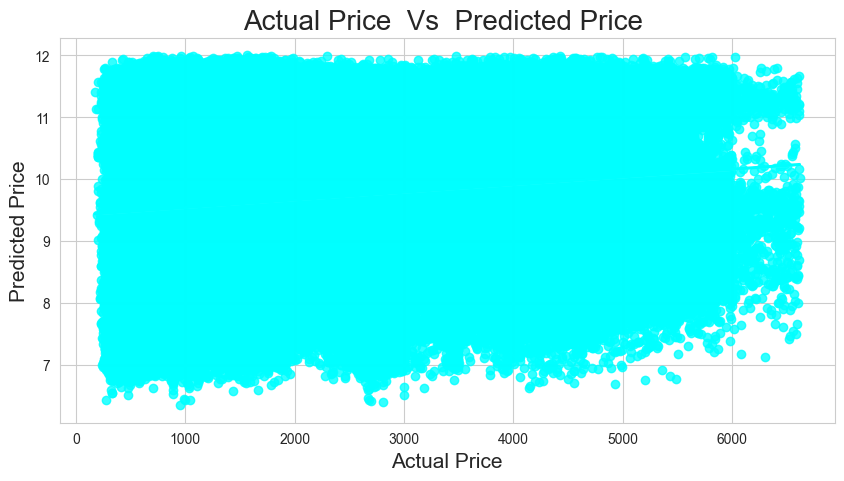

In [21]:
# Plot predictions against actual prices
plt.figure(figsize=(10, 5))
sns.regplot(x='Price', y='Price_Predicted', data=final_result_df, color='cyan')
plt.title('Actual Price  Vs  Predicted Price ', fontsize=20)
plt.xlabel('Actual Price', fontsize=15)
plt.ylabel('Predicted Price', fontsize=15)
plt.show()

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, RANSACRegressor, BayesianRidge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import yeojohnson
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn import metrics
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import HuberRegressor

In [23]:
# Ignore warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
gflightZytedata = pd.read_excel(r"Route_Avg_Prices_12072023.xlsx")

In [30]:
print(gflightZytedata.columns.tolist())

['Route_id', 'Price', 'Year', 'Month', 'Days']


In [33]:
# Clean column names
gflightZytedata.columns = gflightZytedata.columns.str.strip()

# Drop only if those columns exist
cols_to_drop = [
    '# route_history_detail_id',
    'min_end_date',
    'min_price',
    'max_price',
    'create_date',
    'update_date',
    'std_dev_price'
]

gflightZytedata.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Split date only if min_start_date exists
if 'min_start_date' in gflightZytedata.columns:
    gflightZytedata[['Year', 'Month', 'Days']] = (
        gflightZytedata['min_start_date'].astype(str).str.split('-', expand=True)
    )
    gflightZytedata.drop(columns=['min_start_date'], inplace=True)

# Rename only if columns count is 5
if len(gflightZytedata.columns) == 5:
    gflightZytedata.columns = ['Route_id', 'Price', 'Year', 'Month', 'Days']

gflightZytedata.head()

,Route_id,Price,Year,Month,Days
0,6423,513,2024,09,02
1,6423,469,2024,10,01
2,6423,485,2024,05,06
3,6421,788,2024,09,02
4,6423,488,2024,03,04


In [34]:
# Feature Engineering
gflightZytedata['Year'] = gflightZytedata['Year'].astype(int)
gflightZytedata['Month'] = gflightZytedata['Month'].astype(int)
gflightZytedata['Days'] = gflightZytedata['Days'].astype(int)
gflightZytedata['Price'] = gflightZytedata['Price'].astype(int)

In [35]:
# Label Encoding
le = LabelEncoder()
for col in gflightZytedata.columns:
    if gflightZytedata[col].dtype == 'object':
        gflightZytedata[col] = le.fit_transform(gflightZytedata[col])

# Modeling
x = gflightZytedata.drop(['Price'], axis=1)
y = gflightZytedata['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)


In [36]:
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())  # Initial model, this will be replaced later
])

In [37]:
# List of models to evaluate
models = [
    LinearRegression(), Ridge(), Lasso(), BayesianRidge(), ElasticNet(),
    SGDRegressor(), HuberRegressor(), RANSACRegressor(),
    GradientBoostingRegressor(), AdaBoostRegressor(),
    ExtraTreesRegressor(), RandomForestRegressor(), BaggingRegressor(),
    KNeighborsRegressor(), DecisionTreeRegressor(), XGBRegressor()
]

# Dictionary to store results
results = {'Model Name': [], 'MAE': [], 'Adj_R_2': [], 'RMSE': [], 'MAPE': [], 'MSE': [], 'RMSLE': [], 'R2_score': []}

In [38]:
# Train each model and evaluate
for model in models:
    # Update the model in the pipeline
    pipeline.set_params(model=model)

    # Fit the pipeline
    pipeline.fit(x_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(x_test)

    # Evaluation metrics
    mae_value = metrics.mean_absolute_error(y_test, y_pred)
    mse_value = metrics.mean_squared_error(y_test, y_pred)
    r2_value = metrics.r2_score(y_test, y_pred)

    # MAPE
    def MAPE(y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    result = MAPE(y_test, y_pred)

    # Adjusted R squared
    r_squared = round(r2_value, 6)
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-x.shape[1]-1), 6)

    # Save results
    results['Model Name'].append(str(model))
    results['MAE'].append(mae_value)
    results['Adj_R_2'].append(adjusted_r_squared)
    results['RMSE'].append(np.sqrt(mse_value))
    results['MAPE'].append(result)
    results['MSE'].append(mse_value)
    results['RMSLE'].append(np.log(np.sqrt(mse_value)))
    results['R2_score'].append(r2_value)

In [39]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
print(result_df)

                                           Model Name          MAE   Adj_R_2  \
0                             RandomForestRegressor()   176.541546  0.961904   
1                                  BaggingRegressor()   183.027456  0.959179   
2                             DecisionTreeRegressor()   211.793941  0.940681   
3                               ExtraTreesRegressor()   254.358935  0.930922   
4   XGBRegressor(base_score=None, booster=None, ca...   673.112610  0.619621   
5                               KNeighborsRegressor()   667.845357  0.598277   
6                         GradientBoostingRegressor()   763.820842  0.575092   
7                                     BayesianRidge()  1247.818952  0.065110   
8                                             Ridge()  1247.817898  0.065110   
9                                  LinearRegression()  1247.817862  0.065110   
10                                            Lasso()  1247.852395  0.065095   
11                                     S

In [40]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
best_model_name = result_df.loc[0, 'Model Name']
best_model = next(model for model in models if str(model) == best_model_name)

In [41]:
# Train the best model on the entire dataset
pipeline.set_params(model=best_model)
pipeline.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

In [42]:
# Make predictions using the best model
best_model_predictions = pipeline.predict(x)

# Display the predictions
predictions_df = pd.DataFrame({'Price_Predicted': best_model_predictions})
final_result_df = pd.concat([gflightZytedata, predictions_df], axis=1)

# Display the final result DataFrame
final_result_df_sample = final_result_df.sample(min(10, len(final_result_df)))
print(final_result_df_sample)


        Route_id  Price  Year  Month  Days  Price_Predicted
401027      4755   1569  2023      4     7          1780.19
386969       601   3150  2023      3     3          3358.78
191658      1796   4399  2023      4    18          4370.92
100681      4744   1004  2023      9    12          1034.08
342574       947   4280  2023      2    20          4194.73
205496      2008   1387  2022     12    31          1366.54
278871      2570   1077  2023      2    17          1063.14
535515       714   1249  2023      5    22          1305.78
126547       517   1428  2023      5    23          1466.02
6257          97    680  2024      2    20           680.00


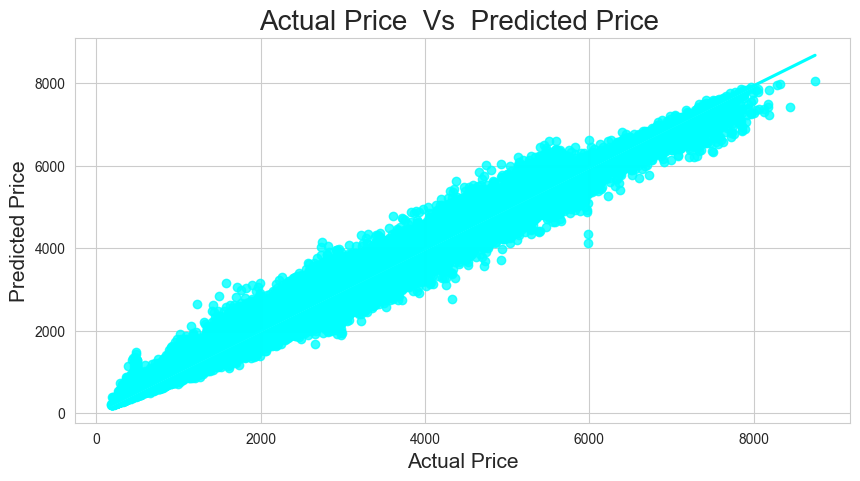

In [43]:
# Plot predictions against actual prices
plt.figure(figsize=(10, 5))
sns.regplot(x='Price', y='Price_Predicted', data=final_result_df, color='cyan')
plt.title('Actual Price  Vs  Predicted Price ', fontsize=20)
plt.xlabel('Actual Price', fontsize=15)
plt.ylabel('Predicted Price', fontsize=15)
plt.show()

In [44]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, RANSACRegressor, BayesianRidge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import yeojohnson
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn import metrics
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [45]:
# Ignore warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

In [46]:
gflightZytedata = pd.read_excel(r"Route_Avg_Prices_12072023.xlsx",nrows=1000)

gflightZytedata

,# route_history_detail_id,route_id,min_start_date,min_end_date,min_price,max_price,create_date,update_date,avg_price,std_dev_price
0,1828744,6423,2024-09-02,2024-09-11,365,692,2023-12-07 16:09:48,2023-12-07 16:09:48,513,37.91
1,1828743,6423,2024-10-01,2024-10-08,365,680,2023-12-07 16:09:26,2023-12-07 16:09:26,469,39.51
2,1828742,6423,2024-05-06,2024-05-15,365,692,2023-12-07 16:09:03,2023-12-07 16:09:03,485,40.01
3,1828741,6421,2024-09-02,2024-09-09,786,800,2023-12-07 16:08:59,2023-12-07 16:08:59,788,7.21
4,1828740,6423,2024-03-04,2024-03-11,365,692,2023-12-07 16:08:41,2023-12-07 16:08:41,488,39.27
...,...,...,...,...,...,...,...,...,...,...
995,1214869,845,2024-02-06,2024-02-13,562,594,2023-04-20 14:45:17,2023-12-07 14:26:19,573,2.94
996,1259020,169,2024-02-06,2024-02-13,828,828,2023-05-11 16:49:42,2023-12-07 14:26:07,828,0.00
997,1161289,3633,2024-02-06,2024-02-13,586,598,2023-03-12 20:07:55,2023-12-07 14:26:04,593,0.00
998,1422257,318,2024-02-06,2024-02-13,345,398,2023-07-20 14:13:39,2023-12-07 14:25:58,372,13.36


In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, RANSACRegressor, BayesianRidge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import yeojohnson
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn import metrics
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler


# Ignore warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

In [50]:
# Load Data
#gflightZytedata = pd.read_excel("D:\Python\Python practise\WebScrapPyhtonSelinium-zyte\FlightRegressionPytorchNN\Route_Avg_Prices_12072023.xlsx")
gflightZytedata = pd.read_excel(r"Route_Avg_Prices_12072023.xlsx")
gflightZytedata
gflightZytedata.drop(columns=['# route_history_detail_id', 'min_end_date','min_price','max_price','create_date','update_date','std_dev_price'], inplace=True)
gflightZytedata['min_start_date'] = gflightZytedata['min_start_date'].astype(str)
gflightZytedata['year'], gflightZytedata['month'], gflightZytedata['days'] = zip(*gflightZytedata['min_start_date'].str.split("-"))
gflightZytedata.drop(columns=['min_start_date'],  inplace=True)
gflightZytedata.columns = ['Route_id', 'Price','Year', 'Month', 'Days']
# gflightZytedata.head()

In [51]:
gflightZytedata.head()

,Route_id,Price,Year,Month,Days
0,6423,513,2024,09,02
1,6423,469,2024,10,01
2,6423,485,2024,05,06
3,6421,788,2024,09,02
4,6423,488,2024,03,04


In [52]:
# Outlier Detection
numeric_cols = gflightZytedata.select_dtypes(include=[np.number])
z = np.abs(stats.zscore(numeric_cols))
mask = (z < 3).all(axis=1)
gflightZytedata = gflightZytedata[mask]

# Feature Engineering
transformed_data, _ = yeojohnson(gflightZytedata['Price'])
gflightZytedata['Price_yeojohnson'] = transformed_data
gflightZytedata[['Year', 'Month', 'Days', 'Price']] = gflightZytedata[['Year', 'Month', 'Days', 'Price']].astype(int)

# Label Encoding
le = LabelEncoder()
for col in gflightZytedata.columns:
    if gflightZytedata[col].dtype == 'object':
        gflightZytedata[col] = le.fit_transform(gflightZytedata[col])

# Modeling
x = gflightZytedata.drop(['Price_yeojohnson', 'Price'], axis=1)
y = gflightZytedata['Price_yeojohnson']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
numeric_columns = x_train.select_dtypes(include=[np.number]).columns
x_train[numeric_columns] = scaler.fit_transform(x_train[numeric_columns])
x_test[numeric_columns] = scaler.transform(x_test[numeric_columns])

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())  # Initial model, this will be replaced later
])

# List of models to evaluate
models = [
    LinearRegression(), Ridge(), Lasso(), BayesianRidge(), ElasticNet(),
    SGDRegressor(), HuberRegressor(), RANSACRegressor(),
    GradientBoostingRegressor(), AdaBoostRegressor(),
    ExtraTreesRegressor(), RandomForestRegressor(), BaggingRegressor(),
    KNeighborsRegressor(), DecisionTreeRegressor(), XGBRegressor()
]

# Dictionary to store results
results = {'Model Name': [], 'MAE': [], 'Adj_R_2': [], 'RMSE': [], 'MAPE': [], 'MSE': [], 'RMSLE': [], 'R2_score': []}

# Hyperparameter grids for RandomizedSearchCV
param_grids = {
    'LinearRegression': {},
    'Ridge': {'alpha': np.logspace(-3, 3, 7)},
    'Lasso': {'alpha': np.logspace(-3, 3, 7)},
    'BayesianRidge': {},
    'ElasticNet': {'alpha': np.logspace(-3, 3, 7), 'l1_ratio': [0.2, 0.4, 0.6, 0.8]},
    'SGDRegressor': {'alpha': np.logspace(-3, 3, 7), 'l1_ratio': [0.2, 0.4, 0.6, 0.8], 'penalty': ['l1', 'l2', 'elasticnet']},
    'HuberRegressor': {'alpha': np.logspace(-3, 3, 7), 'epsilon': [1.1, 1.2, 1.3]},
    'RANSACRegressor': {},
    'GradientBoostingRegressor': {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3]},
    'AdaBoostRegressor': {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3]},
    'ExtraTreesRegressor': {'n_estimators': [50, 100, 150, 200], 'max_depth': [None, 10, 20, 30, 40, 50],
                            'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'RandomForestRegressor': {'n_estimators': [50, 100, 150, 200], 'max_features': ['auto', 'sqrt', 'log2'],
                              'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10],
                              'min_samples_leaf': [1, 2, 4]},
    'BaggingRegressor': {'n_estimators': [10, 50, 100, 200], 'max_samples': [0.5, 0.7, 0.9, 1.0],
                         'max_features': [0.5, 0.7, 0.9, 1.0]},
    'KNeighborsRegressor': {'n_neighbors': list(range(1, 21)), 'weights': ['uniform', 'distance'],
                            'metric': ['euclidean', 'manhattan', 'minkowski']},
    'DecisionTreeRegressor': {'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10],
                              'min_samples_leaf': [1, 2, 4]},
    'XGBRegressor': {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3],
                     'max_depth': [3, 4, 5, 6], 'subsample': [0.8, 0.9, 1.0], 'colsample_bytree': [0.8, 0.9, 1.0]}
}

In [53]:
# Train each model and evaluate
for model in models:
    model_name = str(model)
    # Update the model in the pipeline
    pipeline.set_params(model=model)

    # Check if hyperparameter grid is available
    if model_name in param_grids:
        param_grid = param_grids[model_name]
        
        # Create RandomizedSearchCV
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=10,  # Number of random parameter combinations to try
            scoring='neg_mean_squared_error',
            cv=5,  # Number of cross-validation folds
            random_state=42,
            n_jobs=-1  # Use all available CPU cores
        )
        

         # Fit the RandomizedSearchCV
        random_search.fit(x_train, y_train)
        
        # Set the best parameters to the model
        pipeline.set_params(model=random_search.best_estimator_)

    # Fit the pipeline
    pipeline.fit(x_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(x_test)

    # Evaluation metrics
    mae_value = metrics.mean_absolute_error(y_test, y_pred)
    mse_value = metrics.mean_squared_error(y_test, y_pred)
    r2_value = metrics.r2_score(y_test, y_pred)

    # MAPE
    def MAPE(y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    result = MAPE(y_test, y_pred)

    # Adjusted R squared
    r_squared = round(r2_value, 6)
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-x.shape[1]-1), 6)

    # Save results
    results['Model Name'].append(str(model))
    results['MAE'].append(mae_value)
    results['Adj_R_2'].append(adjusted_r_squared)
    results['RMSE'].append(np.sqrt(mse_value))
    results['MAPE'].append(result)
    results['MSE'].append(mse_value)
    results['RMSLE'].append(np.log(np.sqrt(mse_value)))
    results['R2_score'].append(r2_value)

In [54]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
print(result_df)

                                           Model Name       MAE   Adj_R_2  \
0                             RandomForestRegressor()  0.160394  0.956202   
1                                  BaggingRegressor()  0.165715  0.953250   
2                             DecisionTreeRegressor()  0.191137  0.931223   
3                               ExtraTreesRegressor()  0.240308  0.908385   
4   XGBRegressor(base_score=None, booster=None, ca...  0.572139  0.631700   
5                               KNeighborsRegressor()  0.577566  0.600778   
6                         GradientBoostingRegressor()  0.641533  0.583098   
7                                 AdaBoostRegressor()  0.933497  0.164448   
8                                     BayesianRidge()  0.974966  0.094431   
9                                             Ridge()  0.974967  0.094430   
10                                 LinearRegression()  0.974967  0.094430   
11                                     SGDRegressor()  0.975423  0.094403   

In [55]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
best_model_name = result_df.loc[0, 'Model Name']
best_model = next(model for model in models if str(model) == best_model_name)

# Train the best model on the entire dataset
pipeline.set_params(model=best_model)
pipeline.fit(x, y)

# Make predictions using the best model
best_model_predictions = pipeline.predict(x)

# Display the predictions
predictions_df = pd.DataFrame({'Price_Predicted': best_model_predictions})
final_result_df = pd.concat([gflightZytedata, predictions_df], axis=1)

# Display the final result DataFrame
final_result_df_sample = final_result_df.sample(min(10, len(final_result_df)))
print(final_result_df_sample)

        Route_id   Price    Year  Month  Days  Price_yeojohnson  \
162387    1364.0  2366.0  2023.0    5.0  24.0         10.219804   
145088      22.0  1637.0  2022.0   12.0  28.0          9.604946   
570537    3763.0  1589.0  2023.0    6.0   7.0          9.555937   
112857      78.0   867.0  2023.0   12.0   5.0          8.579655   
484077     577.0  4185.0  2022.0   10.0   4.0         11.202714   
25555     3803.0   471.0  2024.0    3.0   5.0          7.636584   
590253     490.0  1594.0  2023.0    6.0  11.0          9.561106   
356662    1768.0  1011.0  2022.0   11.0   6.0          8.823453   
94431      810.0   495.0  2023.0    8.0  29.0          7.711917   
542540     676.0  1639.0  2022.0   11.0  23.0          9.606959   

        Price_Predicted  
162387        11.321538  
145088         7.579195  
570537         9.236338  
112857         8.585342  
484077         9.828071  
25555         10.464067  
590253              NaN  
356662        11.645740  
94431          8.787893  
54

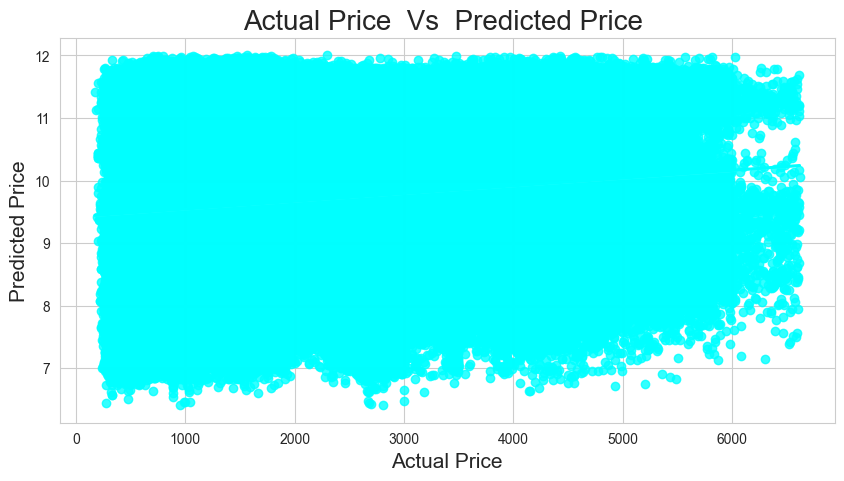

In [56]:
plt.figure(figsize=(10, 5))
sns.regplot(x='Price', y='Price_Predicted', data=final_result_df, color='cyan')
plt.title('Actual Price  Vs  Predicted Price ', fontsize=20)
plt.xlabel('Actual Price', fontsize=15)
plt.ylabel('Predicted Price', fontsize=15)
plt.show()

In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, RANSACRegressor, BayesianRidge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import yeojohnson
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn import metrics
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Ignore warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

# Load Data
#gflightZytedata = pd.read_excel("D:\Python\Python practise\WebScrapPyhtonSelinium-zyte\FlightRegressionPytorchNN\Route_Avg_Prices_12072023.xlsx")
gflightZytedata = pd.read_excel(r"Route_Avg_Prices_12072023.xlsx")


gflightZytedata
gflightZytedata.drop(columns=['# route_history_detail_id', 'min_end_date','min_price','max_price','create_date','update_date','std_dev_price'], inplace=True)
gflightZytedata['min_start_date'] = gflightZytedata['min_start_date'].astype(str)
gflightZytedata['year'], gflightZytedata['month'], gflightZytedata['days'] = zip(*gflightZytedata['min_start_date'].str.split("-"))
gflightZytedata.drop(columns=['min_start_date'], inplace=True)
gflightZytedata.columns = ['Route_id', 'Price','Year', 'Month', 'Days']

In [58]:
gflightZytedata.head()

,Route_id,Price,Year,Month,Days
0,6423,513,2024,09,02
1,6423,469,2024,10,01
2,6423,485,2024,05,06
3,6421,788,2024,09,02
4,6423,488,2024,03,04


In [59]:
# Outlier Detection
numeric_cols = gflightZytedata.select_dtypes(include=[np.number])
z = np.abs(stats.zscore(numeric_cols))
mask = (z < 3).all(axis=1)
gflightZytedata = gflightZytedata[mask]


# Feature Engineering
# transformed_data, _ = stats.yeojohnson(gflightZytedata['Price'])
# gflightZytedata['Price_yeojohnson'] = transformed_data
gflightZytedata['Year'] = gflightZytedata['Year'].astype(int)
gflightZytedata['Month'] = gflightZytedata['Month'].astype(int)
gflightZytedata['Days'] = gflightZytedata['Days'].astype(int)
gflightZytedata['Price'] = gflightZytedata['Price'].astype(int)

# Label Encoding
le = LabelEncoder()
for col in gflightZytedata.columns:
    if gflightZytedata[col].dtype == 'object':
        gflightZytedata[col] = le.fit_transform(gflightZytedata[col])

# Modeling
# x = gflightZytedata.drop(['Price_yeojohnson', 'Price'], axis=1)
x = gflightZytedata.drop(['Price'], axis=1)
# y = gflightZytedata['Price_yeojohnson']
y = gflightZytedata['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)



# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
numeric_columns = x_train.select_dtypes(include=[np.number]).columns
x_train[numeric_columns] = scaler.fit_transform(x_train[numeric_columns])
x_test[numeric_columns] = scaler.transform(x_test[numeric_columns])

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())  # Initial model, this will be replaced later
])

# List of models to evaluate
models = [
    LinearRegression(), Ridge(), Lasso(), BayesianRidge(), ElasticNet(),
    SGDRegressor(), HuberRegressor(), RANSACRegressor(),
    GradientBoostingRegressor(), AdaBoostRegressor(),
    ExtraTreesRegressor(), RandomForestRegressor(), BaggingRegressor(),
    KNeighborsRegressor(), DecisionTreeRegressor(), XGBRegressor()
]

# Dictionary to store results
results = {'Model Name': [], 'MAE': [], 'Adj_R_2': [], 'RMSE': [], 'MAPE': [], 'MSE': [], 'RMSLE': [], 'R2_score': []}

# Hyperparameter grids for RandomizedSearchCV
param_grids = {
    'LinearRegression': {},
    'Ridge': {'alpha': np.logspace(-3, 3, 7)},
    'Lasso': {'alpha': np.logspace(-3, 3, 7)},
    'BayesianRidge': {},
    'ElasticNet': {'alpha': np.logspace(-3, 3, 7), 'l1_ratio': [0.2, 0.4, 0.6, 0.8]},
    'SGDRegressor': {'alpha': np.logspace(-3, 3, 7), 'l1_ratio': [0.2, 0.4, 0.6, 0.8], 'penalty': ['l1', 'l2', 'elasticnet']},
    'HuberRegressor': {'alpha': np.logspace(-3, 3, 7), 'epsilon': [1.1, 1.2, 1.3]},
    'RANSACRegressor': {},
    'GradientBoostingRegressor': {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3]},
    'AdaBoostRegressor': {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3]},
    'ExtraTreesRegressor': {'n_estimators': [50, 100, 150, 200], 'max_depth': [None, 10, 20, 30, 40, 50],
                            'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'RandomForestRegressor': {'n_estimators': [50, 100, 150, 200], 'max_features': ['auto', 'sqrt', 'log2'],
                              'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10],
                              'min_samples_leaf': [1, 2, 4]},
    'BaggingRegressor': {'n_estimators': [10, 50, 100, 200], 'max_samples': [0.5, 0.7, 0.9, 1.0],
                         'max_features': [0.5, 0.7, 0.9, 1.0]},
    'KNeighborsRegressor': {'n_neighbors': list(range(1, 21)), 'weights': ['uniform', 'distance'],
                            'metric': ['euclidean', 'manhattan', 'minkowski']},
    'DecisionTreeRegressor': {'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10],
                              'min_samples_leaf': [1, 2, 4]},
    'XGBRegressor': {'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.2, 0.3],
                     'max_depth': [3, 4, 5, 6], 'subsample': [0.8, 0.9, 1.0], 'colsample_bytree': [0.8, 0.9, 1.0]}
}

In [60]:
# Train each model and evaluate
for model in models:
    model_name = str(model)
    # Update the model in the pipeline
    pipeline.set_params(model=model)

    # Check if hyperparameter grid is available
    if model_name in param_grids:
        param_grid = param_grids[model_name]
        
        # Create RandomizedSearchCV
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=10,  # Number of random parameter combinations to try
            scoring='neg_mean_squared_error',
            cv=5,  # Number of cross-validation folds
            random_state=42,
            n_jobs=-1  # Use all available CPU cores
        )

         # Fit the RandomizedSearchCV
        random_search.fit(x_train, y_train)
        
        # Set the best parameters to the model
        pipeline.set_params(model=random_search.best_estimator_)

    # Fit the pipeline
    pipeline.fit(x_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(x_test)

    # Evaluation metrics
    mae_value = metrics.mean_absolute_error(y_test, y_pred)
    mse_value = metrics.mean_squared_error(y_test, y_pred)
    r2_value = metrics.r2_score(y_test, y_pred)

    # MAPE
    def MAPE(y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    result = MAPE(y_test, y_pred)

    # Adjusted R squared
    r_squared = round(r2_value, 6)
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-x.shape[1]-1), 6)

    # Save results
    results['Model Name'].append(str(model))
    results['MAE'].append(mae_value)
    results['Adj_R_2'].append(adjusted_r_squared)
    results['RMSE'].append(np.sqrt(mse_value))
    results['MAPE'].append(result)
    results['MSE'].append(mse_value)
    results['RMSLE'].append(np.log(np.sqrt(mse_value)))
    results['R2_score'].append(r2_value)


In [61]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
print(result_df)

                                           Model Name          MAE   Adj_R_2  \
0                             RandomForestRegressor()   177.221132  0.962151   
1                                  BaggingRegressor()   182.876632  0.959621   
2                             DecisionTreeRegressor()   212.430553  0.941126   
3                               ExtraTreesRegressor()   241.512095  0.937173   
4   XGBRegressor(base_score=None, booster=None, ca...   670.084900  0.620647   
5                               KNeighborsRegressor()   665.096298  0.596081   
6                         GradientBoostingRegressor()   758.656587  0.580069   
7                                             Lasso()  1245.329213  0.058525   
8                                     BayesianRidge()  1245.277254  0.058520   
9                                             Ridge()  1245.276015  0.058520   
10                                 LinearRegression()  1245.275973  0.058520   
11                                     S

In [64]:
# Results
result_df = pd.DataFrame(results).sort_values(by='R2_score', ascending=False).reset_index(drop=True)
best_model_name = result_df.loc[0, 'Model Name']
best_model = next(model for model in models if str(model) == best_model_name)

# Train the best model on the entire dataset
pipeline.set_params(model=best_model)
pipeline.fit(x, y)
# SAVE MODEL HERE
import pickle

with open("flight_price_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved successfully!")

# Make predictions using the best model
best_model_predictions = pipeline.predict(x)

# Display the predictions
predictions_df = pd.DataFrame({'Price_Predicted': best_model_predictions})
final_result_df = pd.concat([gflightZytedata, predictions_df], axis=1)

# Display the final result DataFrame
final_result_df_sample = final_result_df.sample(min(10, len(final_result_df)))
print(final_result_df_sample)


Model saved successfully!
        Route_id   Price    Year  Month  Days  Price_Predicted
501770    2138.0  1776.0  2023.0    2.0  25.0          1638.41
156948      97.0  1580.0  2022.0   12.0  16.0          1063.74
305051     130.0  4411.0  2023.0    5.0  12.0          1622.17
513795    1218.0  1587.0  2022.0   10.0  28.0           747.60
149040    5393.0  1507.0  2023.0    6.0  28.0          1985.64
280216    1944.0  1449.0  2023.0    3.0  17.0          1866.35
234602     174.0  4775.0  2023.0    2.0   2.0          3806.02
339732    1032.0  4856.0  2023.0    2.0  13.0          4952.95
269446    1319.0  1869.0  2023.0    1.0   2.0          2357.47
75729      510.0   898.0  2024.0    3.0   5.0          2751.65


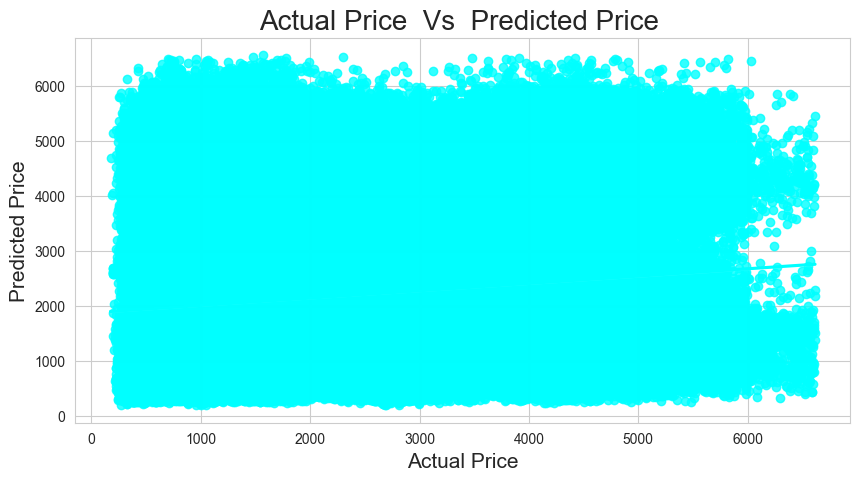

In [65]:
# Plot predictions against actual prices
plt.figure(figsize=(10, 5))
sns.regplot(x='Price', y='Price_Predicted', data=final_result_df, color='cyan')
plt.title('Actual Price  Vs  Predicted Price ', fontsize=20)
plt.xlabel('Actual Price', fontsize=15)
plt.ylabel('Predicted Price', fontsize=15)
plt.show()
